### Open a single grib file to check the contents for the next script, 
The grib files from HRRR-AK keep changing variable names and such, so everytime we download, we have to recheck a single file and adjust the processing script accordingly

created by Cassie Lumbrazo\
last updated: Feb 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_model_forcing/large_juneau_domain'

In [3]:
# adding this for parallel processing
from concurrent.futures import ProcessPoolExecutor

### Open a single grib file to see the current file structure, it keeps changing\
then fix up the variables if needed.

This will print everything going on, open in a text editor and look

In [4]:
import xarray as xr
import numpy as np
import pygrib
import os

# Path to a single GRIB file (replace with your file path)
grib_file = '/hdd/snow_hydrology/hrrrak/large_juneau_domain/f567/WY2025/hrrr.20241001/hrrr.t00z.wrfsfcf05.ak.grib2'

# List of variables we need (based on log; may need adjustment)
needed_vars = ['t', 'sp', 't2m', 'r2', 'sde', 'sdwrf', 'sdlwrf', 'tp', 'prate', 'u10', 'v10']

# Optional: Mapping if short names differ (e.g., {'tmp': 't'})
name_mapping = {}  # Add mappings if needed, e.g., {'tmp': 't'}

# Function to open GRIB file and inspect variables
def inspect_grib_file(file_path):
    grbs = pygrib.open(file_path)
    print(f"Inspecting {file_path}")
    print(f"Total messages (subsets): {grbs.messages}")
    
    var_info = {}
    for i, grb in enumerate(grbs):
        short_name = grb.shortName.lower() if hasattr(grb, 'shortName') else grb.name.lower().replace(' ', '_')
        mapped_name = name_mapping.get(short_name, short_name)
        print(f"Subset {i}: full_name='{grb.name}', short_name='{short_name}', mapped='{mapped_name}', level={grb.level}, typeOfLevel={grb.typeOfLevel}")
        
        if mapped_name in needed_vars:
            print(f"  -> Found needed var: {mapped_name}")
            var_info[mapped_name] = {
                'subset': i,
                'level': grb.level,
                'typeOfLevel': grb.typeOfLevel,
                'data': grb.values,
                'lat': grb.latlons()[0],
                'lon': grb.latlons()[1]
            }
    grbs.close()
    
    if not var_info:
        print("No needed variables found in the file.")
        return None
    return var_info

# Inspect the file
var_info = inspect_grib_file(grib_file)

if var_info is None:
    print("Cannot proceed without variables.")
else:
    # Now, to merge into a single xarray Dataset
    def create_merged_dataset(var_info):
        datasets = []
        
        # Common coordinates (assuming all have the same grid)
        first_var = list(var_info.keys())[0]
        lat = var_info[first_var]['lat']
        lon = var_info[first_var]['lon']
        
        for var_name, info in var_info.items():
            data = info['data']
            level = info['level']
            type_level = info['typeOfLevel']
            
            # Create DataArray with appropriate dimensions
            if type_level == 'isobaricInhPa' and var_name == 't':
                # For temperature at pressure levels, add pressure as a dimension
                da = xr.DataArray(
                    data[np.newaxis, :, :],  # Add pressure dimension
                    dims=['isobaricInhPa', 'y', 'x'],
                    coords={
                        'isobaricInhPa': [level],
                        'y': range(data.shape[0]),
                        'x': range(data.shape[1]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon)
                    },
                    name=var_name
                )
            elif type_level == 'heightAboveGround' and level == 10 and var_name in ['u10', 'v10']:
                # 10m winds
                da = xr.DataArray(
                    data,
                    dims=['y', 'x'],
                    coords={
                        'y': range(data.shape[0]),
                        'x': range(data.shape[1]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon),
                        'heightAboveGround': level
                    },
                    name=var_name
                )
            elif type_level == 'heightAboveGround' and level == 2 and var_name in ['t2m', 'r2']:
                # 2m variables
                da = xr.DataArray(
                    data,
                    dims=['y', 'x'],
                    coords={
                        'y': range(data.shape[0]),
                        'x': range(data.shape[1]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon),
                        'heightAboveGround': level
                    },
                    name=var_name
                )
            elif type_level == 'surface' or (type_level == 'heightAboveGround' and level == 0):
                # Surface variables
                da = xr.DataArray(
                    data,
                    dims=['y', 'x'],
                    coords={
                        'y': range(data.shape[0]),
                        'x': range(data.shape[1]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon)
                    },
                    name=var_name
                )
            else:
                # Default for others
                da = xr.DataArray(
                    data,
                    dims=['y', 'x'],
                    coords={
                        'y': range(data.shape[0]),
                        'x': range(data.shape[1]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon)
                    },
                    name=var_name
                )
            
            datasets.append(da)
        
        # Merge all DataArrays into a single Dataset
        merged_ds = xr.merge(datasets)
        return merged_ds

    # Create and inspect the merged dataset
    merged_ds = create_merged_dataset(var_info)
    print(merged_ds)

    # # Save to NetCDF
    # output_nc = '/path/to/output/file.nc'  # Replace with desired output path
    # merged_ds.to_netcdf(output_nc)
    # print(f"Saved merged dataset to {output_nc}")

Inspecting /hdd/snow_hydrology/hrrrak/large_juneau_domain/f567/WY2025/hrrr.20241001/hrrr.t00z.wrfsfcf05.ak.grib2
Total messages (subsets): 171
Subset 0: full_name='Maximum/Composite radar reflectivity', short_name='refc', mapped='refc', level=0, typeOfLevel=atmosphere
Subset 1: full_name='unknown', short_name='unknown', mapped='unknown', level=0, typeOfLevel=cloudTop
Subset 2: full_name='unknown', short_name='unknown', mapped='unknown', level=0, typeOfLevel=atmosphere
Subset 3: full_name='Vertically-integrated liquid', short_name='veril', mapped='veril', level=0, typeOfLevel=atmosphere
Subset 4: full_name='Visibility', short_name='vis', mapped='vis', level=0, typeOfLevel=surface
Subset 5: full_name='Derived radar reflectivity', short_name='refd', mapped='refd', level=1000, typeOfLevel=heightAboveGround
Subset 6: full_name='Derived radar reflectivity', short_name='refd', mapped='refd', level=4000, typeOfLevel=heightAboveGround
Subset 7: full_name='Derived radar reflectivity', short_name

In [5]:
merged_ds 

<xarray.Dataset> Size: 32kB
Dimensions:    (y: 25, x: 20)
Coordinates:
  * y          (y) int64 200B 0 1 2 3 4 5 6 7 8 9 ... 16 17 18 19 20 21 22 23 24
  * x          (x) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
    latitude   (y, x) float64 4kB 58.16 58.16 58.16 58.16 ... 58.8 58.8 58.8
    longitude  (y, x) float64 4kB -135.0 -135.0 -134.9 ... -134.2 -134.1 -134.1
Data variables:
    t          (y, x) float64 4kB 282.6 282.6 282.6 282.6 ... 269.6 271.1 271.6
    sp         (y, x) float64 4kB 9.97e+04 9.97e+04 ... 8.212e+04 8.312e+04
    sde        (y, x) float64 4kB 0.0 0.0 0.0 0.0 ... 42.76 47.81 37.32 32.11
    prate      (y, x) float64 4kB 0.00079 0.00078 0.00072 ... 0.00113 0.00106
    tp         (y, x) float64 4kB 0.963 0.69 0.409 0.369 ... 3.562 4.314 4.232
    sdlwrf     (y, x) float64 4kB 347.9 347.8 347.8 347.5 ... 282.9 303.1 306.6

### Now, this code processes that grib file, 
and will be used to make the next script for processing all the variables 

In [ ]:
import xarray as xr
import numpy as np
import pygrib
import os

# Path to a single GRIB file
grib_file = '/hdd/snow_hydrology/hrrrak/large_juneau_domain/f567/WY2025/hrrr.20241001/hrrr.t00z.wrfsfcf05.ak.grib2'

# List of desired variables (short names from GRIB output, keeping naming conventions)
# Main important for modeling (simplified: only surface temp, 2m temp, 10m winds)
desired_vars = [
    't',        # Temperature (only surface level now)
    'sp',       # Surface pressure
    '2t',       # 2 metre temperature
    '2r',       # 2 metre relative humidity
    'tp',       # Total Precipitation
    'prate',    # Precipitation rate
    '10u',      # 10 metre U wind component
    '10v',      # 10 metre V wind component
    'sdswrf',   # Surface downward short-wave radiation flux
    'sdlwrf',   # Surface downward long-wave radiation flux
    # Extras
    'gust',     # Wind speed (gust)
    'tcc',      # Total Cloud Cover
    'lcc',      # Low cloud cover
    'mcc',      # Medium cloud cover
    'hcc',      # High cloud cover
    'lai',      # Leaf Area Index
    '2d',       # 2 metre dewpoint temperature
    '2sh',      # 2 metre specific humidity
    'suswrf',   # Surface upward short-wave radiation flux
    'sulwrf',   # Surface upward long-wave radiation flux
    'orog',     # Orography
    'sdwe',     # Water equivalent of accumulated snow depth
    'sde',      # Snow depth
    'veg',      # Vegetation
    'vgtyp',    # Vegetation Type
    'gflux',    # Ground heat flux
]

# Function to open GRIB file and collect desired variables
def collect_desired_vars(file_path, desired_vars):
    grbs = pygrib.open(file_path)
    var_info = {}
    
    for grb in grbs:
        short_name = grb.shortName.lower()
        if short_name in desired_vars:
            # Special filter: for 't', only keep surface level
            if short_name == 't' and not (grb.typeOfLevel == 'surface'):
                continue
            key = f"{short_name}_{grb.level}_{grb.typeOfLevel}"  # Unique key
            var_info[key] = {
                'short_name': short_name,
                'level': grb.level,
                'typeOfLevel': grb.typeOfLevel,
                'data': grb.values,
                'lat': grb.latlons()[0],
                'lon': grb.latlons()[1]
            }
    grbs.close()
    return var_info

# Function to create merged xarray Dataset
def create_merged_dataset(var_info):
    datasets = []
    
    # Get common lat/lon from first var
    first_key = list(var_info.keys())[0]
    lat = var_info[first_key]['lat']
    lon = var_info[first_key]['lon']
    
    # Group vars by short_name AND typeOfLevel for proper handling
    grouped_vars = {}
    for key, info in var_info.items():
        group_key = f"{info['short_name']}_{info['typeOfLevel']}"
        if group_key not in grouped_vars:
            grouped_vars[group_key] = []
        grouped_vars[group_key].append(info)
    
    for group_key, infos in grouped_vars.items():
        short_name = infos[0]['short_name']
        type_level = infos[0]['typeOfLevel']
        
        if len(infos) == 1:
            # Single level var
            info = infos[0]
            data = info['data']
            level = info['level']
            
            if type_level == 'surface' or (type_level == 'heightAboveGround' and level == 0):
                da = xr.DataArray(
                    data,
                    dims=['y', 'x'],
                    coords={
                        'y': range(data.shape[0]),
                        'x': range(data.shape[1]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon)
                    },
                    name=short_name
                )
            elif type_level == 'heightAboveGround' and level in [2, 10]:
                da = xr.DataArray(
                    data,
                    dims=['y', 'x'],
                    coords={
                        'y': range(data.shape[0]),
                        'x': range(data.shape[1]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon)
                    },
                    attrs={'heightAboveGround': level},  # Add as attribute
                    name=short_name
                )
            else:
                da = xr.DataArray(
                    data,
                    dims=['y', 'x'],
                    coords={
                        'y': range(data.shape[0]),
                        'x': range(data.shape[1]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon)
                    },
                    name=short_name
                )
            datasets.append(da)
        
        else:
            # Multi-level var (same typeOfLevel, different levels) - but with filtering, this should be rare now
            levels = [info['level'] for info in infos]
            data_stack = np.stack([info['data'] for info in infos], axis=0)
            
            if type_level == 'isobaricInhPa':
                da = xr.DataArray(
                    data_stack,
                    dims=['isobaricInhPa', 'y', 'x'],
                    coords={
                        'isobaricInhPa': levels,
                        'y': range(data_stack.shape[1]),
                        'x': range(data_stack.shape[2]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon)
                    },
                    name=short_name
                )
            elif type_level == 'heightAboveGround':
                da = xr.DataArray(
                    data_stack,
                    dims=['heightAboveGround', 'y', 'x'],
                    coords={
                        'heightAboveGround': levels,
                        'y': range(data_stack.shape[1]),
                        'x': range(data_stack.shape[2]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon)
                    },
                    name=short_name
                )
            else:
                # Fallback for other multi-level (e.g., tcc with different layers)
                da = xr.DataArray(
                    data_stack,
                    dims=['level', 'y', 'x'],
                    coords={
                        'level': levels,
                        'y': range(data_stack.shape[1]),
                        'x': range(data_stack.shape[2]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon)
                    },
                    name=short_name
                )
            datasets.append(da)
    
    # Merge all DataArrays into a single Dataset, allowing coord overrides
    merged_ds = xr.merge(datasets, compat='override')
    return merged_ds

# Collect vars
var_info = collect_desired_vars(grib_file, desired_vars)

if not var_info:
    print("No desired variables found.")
else:
    # Create merged dataset
    merged_ds = create_merged_dataset(var_info)
    print(merged_ds)
    
    # # Save to NetCDF
    # output_nc = '/path/to/output/merged_vars.nc'  # Replace with desired output path
    # merged_ds.to_netcdf(output_nc)
    # print(f"Saved merged dataset to {output_nc}")

<xarray.Dataset> Size: 112kB
Dimensions:    (y: 25, x: 20)
Coordinates:
  * y          (y) int64 200B 0 1 2 3 4 5 6 7 8 9 ... 16 17 18 19 20 21 22 23 24
  * x          (x) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
    latitude   (y, x) float64 4kB 58.16 58.16 58.16 58.16 ... 58.8 58.8 58.8
    longitude  (y, x) float64 4kB -135.0 -135.0 -134.9 ... -134.2 -134.1 -134.1
Data variables: (12/26)
    gust       (y, x) float64 4kB 15.12 15.62 16.12 16.37 ... 11.0 8.684 7.371
    sp         (y, x) float64 4kB 9.97e+04 9.97e+04 ... 8.212e+04 8.312e+04
    orog       (y, x) float64 4kB -0.01151 -0.01151 ... 1.612e+03 1.518e+03
    t          (y, x) float64 4kB 282.6 282.6 282.6 282.6 ... 269.6 271.1 271.6
    sdwe       (y, x) float64 4kB 0.0 0.0 0.0 0.0 0.0 ... 2.92 3.452 4.111 3.999
    sde        (y, x) float64 4kB 0.0 0.0 0.0 0.0 ... 42.76 47.81 37.32 32.11
    ...         ...
    mcc        (y, x) float64 4kB 100.0 100.0 100.0 100.0 ... 100.0 100.0 100.0
    hcc        (

In [7]:
merged_ds

<xarray.Dataset> Size: 112kB
Dimensions:    (y: 25, x: 20)
Coordinates:
  * y          (y) int64 200B 0 1 2 3 4 5 6 7 8 9 ... 16 17 18 19 20 21 22 23 24
  * x          (x) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
    latitude   (y, x) float64 4kB 58.16 58.16 58.16 58.16 ... 58.8 58.8 58.8
    longitude  (y, x) float64 4kB -135.0 -135.0 -134.9 ... -134.2 -134.1 -134.1
Data variables: (12/26)
    gust       (y, x) float64 4kB 15.12 15.62 16.12 16.37 ... 11.0 8.684 7.371
    sp         (y, x) float64 4kB 9.97e+04 9.97e+04 ... 8.212e+04 8.312e+04
    orog       (y, x) float64 4kB -0.01151 -0.01151 ... 1.612e+03 1.518e+03
    t          (y, x) float64 4kB 282.6 282.6 282.6 282.6 ... 269.6 271.1 271.6
    sdwe       (y, x) float64 4kB 0.0 0.0 0.0 0.0 0.0 ... 2.92 3.452 4.111 3.999
    sde        (y, x) float64 4kB 0.0 0.0 0.0 0.0 ... 42.76 47.81 37.32 32.11
    ...         ...
    mcc        (y, x) float64 4kB 100.0 100.0 100.0 100.0 ... 100.0 100.0 100.0
    hcc        (y, x) float64 4kB 79.0 78.0 86.0 92.0 ... 100.0 100.0 100.0
    sdswrf     (y, x) float64 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    sdlwrf     (y, x) float64 4kB 347.9 347.8 347.8 347.5 ... 282.9 303.1 306.6
    suswrf     (y, x) float64 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    sulwrf     (y, x) float64 4kB 354.7 354.6 354.6 354.7 ... 293.6 300.2 302.2

In [8]:
merged_ds['2t']

<xarray.DataArray '2t' (y: 25, x: 20)> Size: 4kB
array([[282.73641968, 282.79891968, 282.79891968, 282.79891968,
        279.42391968, 281.04891968, 281.61141968, 282.17391968,
        281.98641968, 280.92391968, 280.42391968, 281.29891968,
        281.86141968, 282.11141968, 282.04891968, 281.79891968,
        281.67391968, 281.86141968, 281.92391968, 280.42391968],
       [282.79891968, 282.86141968, 282.92391968, 281.11141968,
        277.48641968, 280.73641968, 281.79891968, 282.48641968,
        282.42391968, 282.36141968, 282.29891968, 282.36141968,
        282.48641968, 282.42391968, 282.17391968, 281.92391968,
        281.98641968, 281.98641968, 281.86141968, 280.73641968],
       [282.79891968, 282.92391968, 282.98641968, 279.42391968,
        277.48641968, 280.54891968, 281.79891968, 282.86141968,
        282.79891968, 282.61141968, 282.54891968, 282.54891968,
        282.17391968, 279.98641968, 279.86141968, 282.11141968,
        281.04891968, 281.86141968, 281.67391968, 280.73641968],
       [282.61141968, 282.73641968, 282.92391968, 280.98641968,
        280.23641968, 280.73641968, 283.11141968, 283.17391968,
        282.73641968, 279.42391968, 279.29891968, 279.23641968,
        277.61141968, 279.48641968, 281.48641968, 279.17391968,
        278.79891968, 278.11141968, 281.48641968, 281.23641968],
...
       [282.61141968, 282.67391968, 281.42391968, 278.29891968,
        274.42391968, 275.17391968, 275.11141968, 276.23641968,
        276.61141968, 276.79891968, 273.23641968, 274.73641968,
        272.79891968, 272.67391968, 272.42391968, 272.17391968,
        271.92391968, 271.98641968, 272.54891968, 271.61141968],
       [282.61141968, 283.23641968, 281.42391968, 274.29891968,
        273.86141968, 279.73641968, 278.29891968, 275.92391968,
        277.92391968, 279.92391968, 276.92391968, 277.54891968,
        273.92391968, 272.86141968, 272.42391968, 271.73641968,
        271.86141968, 271.48641968, 271.98641968, 271.92391968],
       [282.11141968, 283.73641968, 280.48641968, 274.54891968,
        277.98641968, 280.48641968, 280.54891968, 280.79891968,
        279.86141968, 276.98641968, 278.42391968, 278.48641968,
        276.92391968, 275.17391968, 272.73641968, 270.17391968,
        271.17391968, 269.92391968, 271.29891968, 271.11141968],
       [281.54891968, 282.67391968, 280.98641968, 278.54891968,
        280.92391968, 278.98641968, 276.61141968, 278.04891968,
        273.48641968, 273.61141968, 276.29891968, 277.48641968,
        274.17391968, 272.36141968, 271.86141968, 269.67391968,
        270.29891968, 269.67391968, 271.11141968, 271.61141968]])
Coordinates:
  * y          (y) int64 200B 0 1 2 3 4 5 6 7 8 9 ... 16 17 18 19 20 21 22 23 24
  * x          (x) int64 160B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
    latitude   (y, x) float64 4kB 58.16 58.16 58.16 58.16 ... 58.8 58.8 58.8
    longitude  (y, x) float64 4kB -135.0 -135.0 -134.9 ... -134.2 -134.1 -134.1
Attributes:
    heightAboveGround:  2

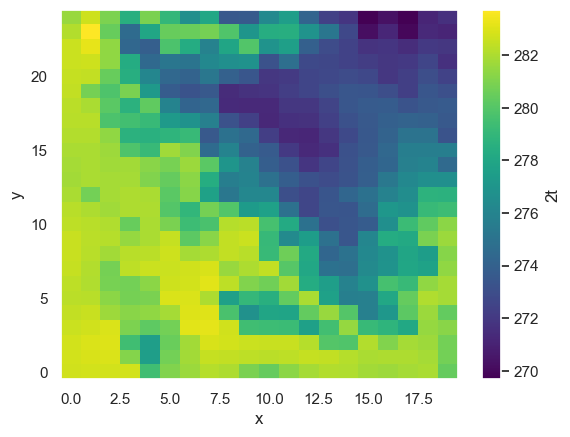

In [9]:
merged_ds['2t'].plot()